<a href="https://colab.research.google.com/github/Kman0908/Fuddu/blob/main/hard_hat_workers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from roboflow import Roboflow
from google.colab import userdata

rf = Roboflow(api_key=userdata.get("RoboFlow"))
project = rf.workspace("joseph-nelson").project("hard-hat-workers")
dataset = project.version(1).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Hard-Hat-Workers-1 in yolov8:: 100%|██████████| 14079/14079 [00:01<00:00, 7291.89it/s] 


In [ ]:
import os
for root, dirs, files in os.walk(dataset.location):
    print(f"DIR: {root}")
    for file in files:
        print(f"  FILE: {file}")

DIR: /content/Hard-Hat-Workers-1
  FILE: data.yaml
  FILE: README.roboflow.txt
  FILE: README.dataset.txt
DIR: /content/Hard-Hat-Workers-1/test
DIR: /content/Hard-Hat-Workers-1/test/images
  FILE: 006424_jpg.rf.799bc1fafcbe9552802f96a0be97a9b9.jpg
  FILE: 006152_jpg.rf.c0bbaf37495c11bc85f9b28b4388ca63.jpg
  FILE: 006222_jpg.rf.d884d6eb44f54e68b815ed8761e35263.jpg
  FILE: 006002_jpg.rf.dff006f1eca0a0cac68bc82862eea8d3.jpg
  FILE: 005982_jpg.rf.de25d5e3c377439f61db5fa79ec84361.jpg
  FILE: 007007_jpg.rf.f84bc35aaa00a4475cd1dda88d5c1113.jpg
  FILE: 006942_jpg.rf.69b367a2a0c171cf3d7791046e544eb3.jpg
  FILE: 005584_jpg.rf.acfcb183cca353f6bc7ba0231dc8dbe0.jpg
  FILE: 006637_jpg.rf.74186ee91b06d8db5e9666ae21edfda8.jpg
  FILE: 007027_jpg.rf.3040d948aae1023426493440eea61e6e.jpg
  FILE: 006644_jpg.rf.225fc2aa36dcf51aa13348940f5c8b91.jpg
  FILE: 006485_jpg.rf.7e043f5545ba9f360b68e376046fa9c5.jpg
  FILE: 005382_jpg.rf.7307d6f5141c9628e184de8fabfe2e33.jpg
  FILE: 006833_jpg.rf.5ccaf85014387e5dd8d2aa

In [ ]:
from ultralytics import YOLO

In [ ]:
import yaml

data_yaml_path = f"{dataset.location}/data.yaml"

with open(data_yaml_path, "r") as f:
    data = yaml.safe_load(f)

# Overwrite with absolute paths
data["train"] = f"{dataset.location}/train/images"
data["test"] = f"{dataset.location}/test/images"
data["val"] = f"{dataset.location}/test/images"

with open(data_yaml_path, "w") as f:
    yaml.dump(data, f)

# Verify
with open(data_yaml_path, "r") as f:
    print(f.read())

names:
- head
- helmet
- person
nc: 3
roboflow:
  license: Public Domain
  project: hard-hat-workers
  url: https://universe.roboflow.com/joseph-nelson/hard-hat-workers/dataset/1
  version: 1
  workspace: joseph-nelson
test: /content/Hard-Hat-Workers-1/test/images
train: /content/Hard-Hat-Workers-1/train/images
val: /content/Hard-Hat-Workers-1/test/images



In [ ]:
model = YOLO('yolov8n.pt')
model.train(data = f'{dataset.location}/data.yaml', epochs = 50)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Hard-Hat-Workers-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pe

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7adea6e763c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [ ]:
test_images_path = f"{dataset.location}/test/images"
results = model.predict(source=test_images_path, conf=0.25, save=True)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1766 /content/Hard-Hat-Workers-1/test/images/005298_jpg.rf.7d1070e4a462d4c636a68e64f2013761.jpg: 640x640 9 helmets, 8.5ms
image 2/1766 /content/Hard-Hat-Workers-1/test/images/005299_jpg.rf.a79cacc62cdd99ad871cf1786ad865ff.jpg: 640x640 1 helmet, 7.4ms
image 3/1766 /content/Hard-Hat-Workers-1/test/images/005300_jpg.rf.419d88422f77db5d30bbb0e769c7c600.jpg: 640x640 1 helmet, 7.0ms
image 4/1766 /content/Hard-Hat-Workers-1/test/images/005301_jpg.rf.c95

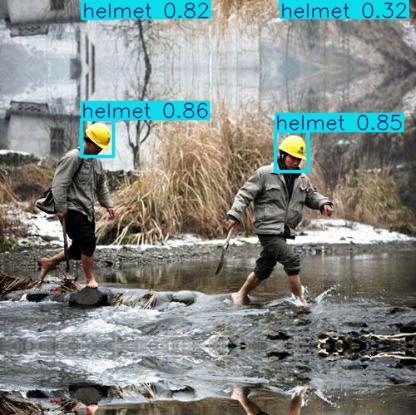

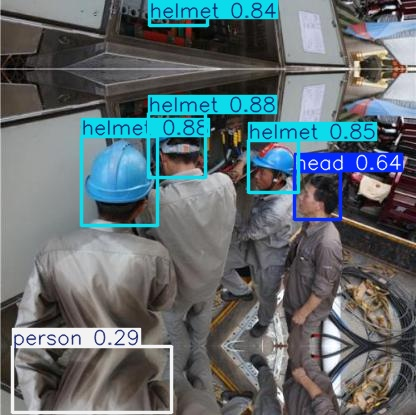

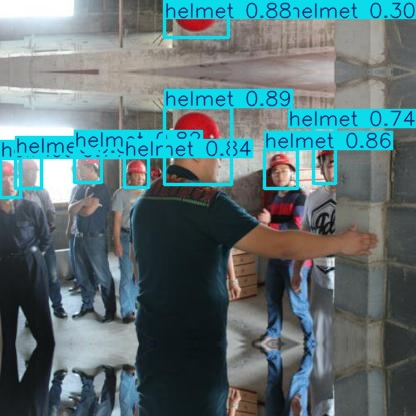

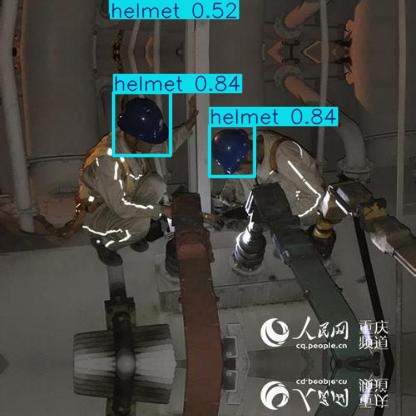

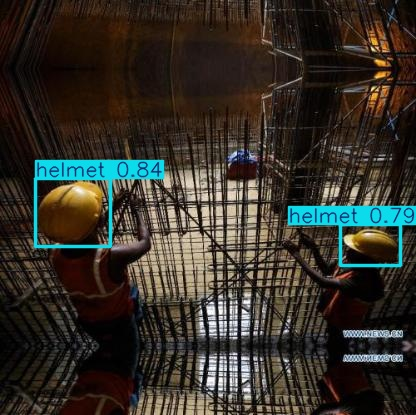

In [ ]:
import glob
from IPython.display import Image, display

predicted_images = glob.glob("/content/runs/detect/predict/*.jpg")[:5]

for img_path in predicted_images:
    display(Image(filename=img_path, width=600))

In [ ]:
# Evaluate on test set
metrics = model.val(data=f"{dataset.location}/data.yaml", split="test")
print(f"mAP50: {metrics.box.map50:.3f}")
print(f"mAP50-95: {metrics.box.map:.3f}")

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1146.2±516.6 MB/s, size: 32.4 KB)
val: Scanning /content/Hard-Hat-Workers-1/test/labels.cache... 1766 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1766/1766 493.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 111/111 5.9it/s 18.9s
                   all       1766       8915      0.637      0.627      0.648      0.437
                  head        339       2208      0.896      0.925      0.947      0.639
                helmet       1604       6482      0.914       0.94      0.967      0.658
                person         45        225     0.0998     0.0178     0.0281     0.0149
Speed: 1.3ms preprocess, 3.7ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/runs/detect/val
mAP50: 0.648
mAP50-95: 0.437


In [ ]:
import shutil
from google.colab import  files

shutil.copy('/content/runs/detect/train5/weights/best.pt', '/content/best.pt')
files.download('/content/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>